# Centrality Measures

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
import pandas as pd
from tqdm.autonotebook import tqdm,trange
%matplotlib inline


## Node centrality analysis: measures and their relation

Centrality analysis allows us to identify important nodes in a network, with the definition of importance depending on the network that we analyze and the nature of the relations that it models. There are a lot of well-known centrality measures, and NetworkX provides implementations for many of them (you can see the list of centrality measures at [centrality documentation](https://networkx.github.io/documentation/stable/reference/algorithms/centrality.html). 

We'll focus here on four essential centrality measures -- degree, betweenness, closeness, eigenvector.

### Florentine Family Graph

We'll use as an example the network of relations between elite families in renaissance Florence. Edges represent marriage ties between families. NetworkX provides this network of florentine families as an undirected graph.

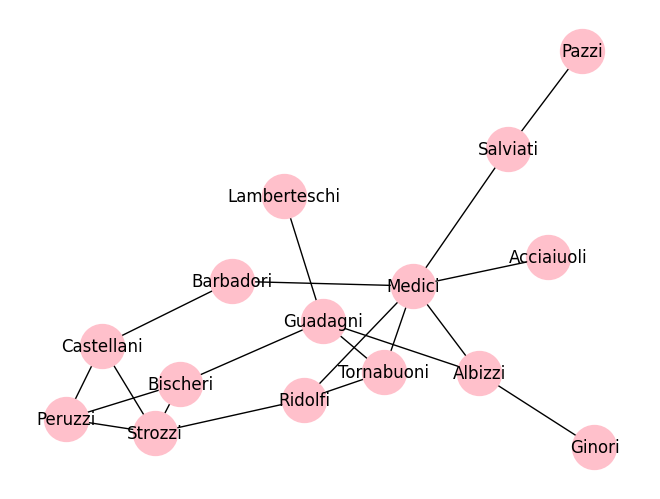

In [2]:
F = nx.florentine_families_graph()
nx.draw(F, node_color='pink', with_labels=True,node_size=1000)

### Degree Centrality

The degree of a node in an undirected graph is the number of edges incident to the node, that is, the number of neighbors that it has on the graph.

Degree centrality often refers to a normalized version of degree, commonly defined as the degree divided by  $n-1$, where $n$ is the total number of nodes of the graph. This is the definition used in NetworkX.

The output of the function `nx.degree_centrality` is a dictionary whose keys are the nodes and their value is the degree centrality. Functions that implement node level measures in NetworkX, such as centrality scores, always return their result as a dictionary, with nodes as keys and the concrete score for that node as a value.

In [3]:
degc = nx.degree_centrality(F)
# let's list the scores
pd.DataFrame.from_dict(degc,orient='index',columns=["Degree Centrality",]).sort_values("Degree Centrality",ascending=False)

,Degree Centrality
Medici,0.428571
Strozzi,0.285714
Guadagni,0.285714
Castellani,0.214286
Peruzzi,0.214286
Ridolfi,0.214286
Tornabuoni,0.214286
Albizzi,0.214286
Bischeri,0.214286
Barbadori,0.142857


### Betweenness centrality

Betweenness centrality of a node `v` is the sum of the fraction of all-pairs shortest paths that pass through `v`. NetworkX uses the definition below. 

$$ c_B(v) =\sum_{s,t \in V} \frac{\sigma(s, t|v)}{\sigma(s, t)} $$

where `V` is the set of nodes, $\sigma(s, t)$ is the number of shortest `(s, t)`-paths,  and $\sigma(s, t|v)$ is the number of those paths passing through node $v$.

In [4]:
bet = nx.betweenness_centrality(F)
# let's list the scores
pd.DataFrame.from_dict(bet,orient='index',columns=["Betweeness Centrality",]).sort_values("Betweeness Centrality",ascending=False)

,Betweeness Centrality
Medici,0.521978
Guadagni,0.254579
Albizzi,0.212454
Salviati,0.142857
Ridolfi,0.113553
Bischeri,0.104396
Strozzi,0.102564
Barbadori,0.093407
Tornabuoni,0.091575
Castellani,0.054945


### Closeness centrality

Closeness centrality of a node `u` is the reciprocal of the sum of the shortest path distances from `u` to all `n-1` other nodes. In NetworkX, closeness is normalized by the sum of minimum possible distances `n-1`

$$C(u) = \frac{n - 1}{\sum_{v=1}^{n-1} d(v, u)}$$

where `d(v, u)` is the shortest-path distance between `v` and `u`, and `n` is the number of nodes in the graph. Notice that higher values of closeness indicate higher centrality.


In [5]:
clos = nx.closeness_centrality(F)
# let's list the scores
pd.DataFrame.from_dict(clos,orient='index',columns=["Closeness Centrality",]).sort_values("Closeness Centrality",ascending=False)

,Closeness Centrality
Medici,0.560000
Ridolfi,0.500000
Tornabuoni,0.482759
Albizzi,0.482759
Guadagni,0.466667
Strozzi,0.437500
Barbadori,0.437500
Bischeri,0.400000
Castellani,0.388889
Salviati,0.388889


### Eigenvector Centrality

Eigenvector centrality assigns relative scores to all nodes in the network based on the concept that connections from high-scoring nodes contribute more to the score of the node in question than connections to low-scoring nodes.

Google's pagerank score is a variant of eigenvector centrality (NetworkX also implements the pagerank algorithm).

In [6]:
eig = nx.eigenvector_centrality(F)
# let's list the scores
pd.DataFrame.from_dict(eig,orient='index',columns=["Eigenvector Centrality",]).sort_values("Eigenvector Centrality",ascending=False)

,Eigenvector Centrality
Medici,0.430315
Strozzi,0.355973
Ridolfi,0.341554
Tornabuoni,0.325847
Guadagni,0.289117
Bischeri,0.282794
Peruzzi,0.275722
Castellani,0.259020
Albizzi,0.243961
Barbadori,0.211706


### Relation between centrality measures 

As we can see the Medici family is the most central node in the network according to all four centrality measures analyzed here. This is not always the case. When analyzing the node centrality of a network is important to think about the kind of relations that it models, and choose the centrality measure that captures the notion of centrality/importance that suits our purposes.

In practice it's useful to plot the relations between centrality scores to see their correlation and see up to which point they provide redundant information. We can do this easily using Pandas and seaborn.

In [7]:
import pandas as pd
import seaborn as sns

In [8]:
centrality_measures = {
    'Degree': degc,
    'Betweenness': bet,
    'Closeness': clos,
    'Eigenvector': eig,
}
centrality = pd.DataFrame(centrality_measures)
centrality

,Degree,Betweenness,Closeness,Eigenvector
Acciaiuoli,0.071429,0.000000,0.368421,0.132157
Medici,0.428571,0.521978,0.560000,0.430315
Castellani,0.214286,0.054945,0.388889,0.259020
Peruzzi,0.214286,0.021978,0.368421,0.275722
Strozzi,0.285714,0.102564,0.437500,0.355973
Barbadori,0.142857,0.093407,0.437500,0.211706
Ridolfi,0.214286,0.113553,0.500000,0.341554
Tornabuoni,0.214286,0.091575,0.482759,0.325847
Albizzi,0.214286,0.212454,0.482759,0.243961
Salviati,0.142857,0.142857,0.388889,0.145921


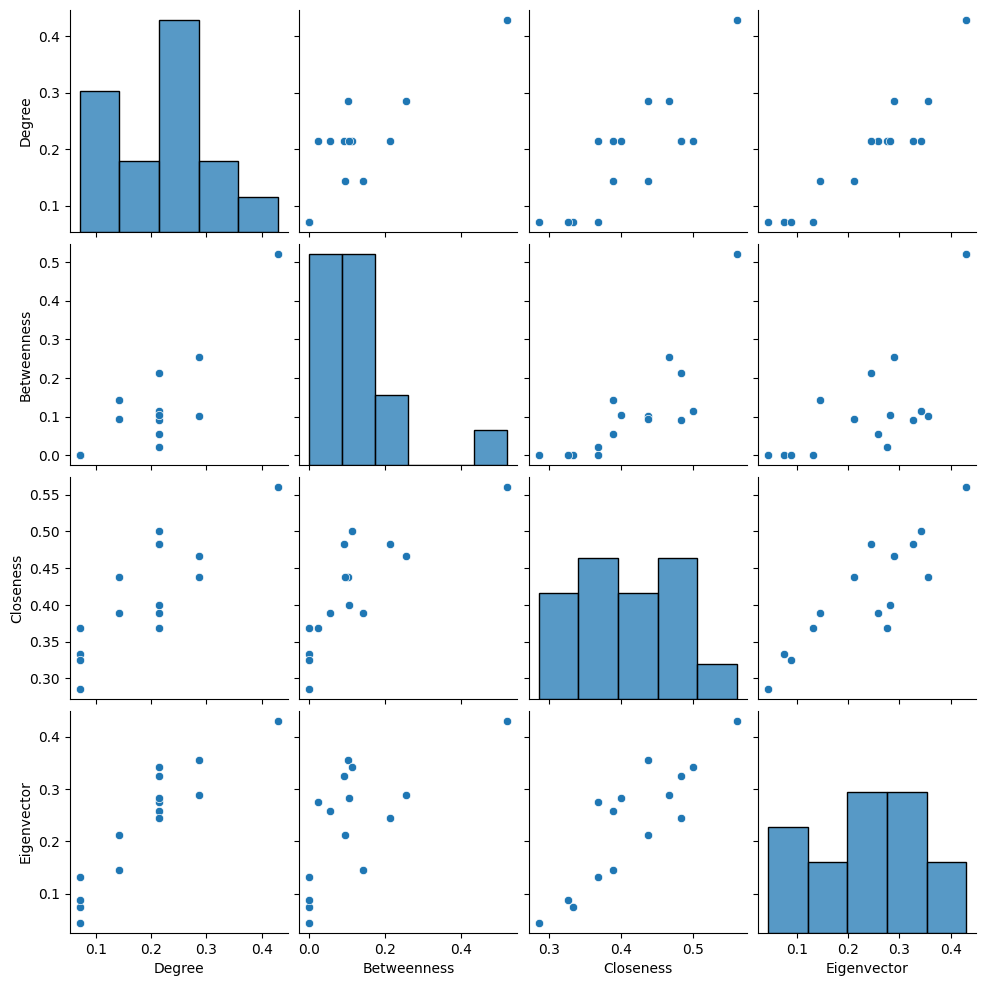

In [9]:
sns.pairplot(centrality)